[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/pytorch-mastery/blob/main/03_advanced_architectures/diffusion_models.ipynb)


# 07 . Diffusion Models (DDPM) on 2-D Data

## Concept — Denoising Diffusion Models (revision notes)

**What it is**
- A generative model built from two processes. The *forward* process
  gradually destroys data by adding a little Gaussian noise at each of `T`
  steps until only pure noise remains. The *reverse* process is a neural
  network that learns to undo that noising one step at a time; running it from
  pure noise generates new data.

**Why it matters**
- Training is a simple, stable regression problem (no adversarial game, no
  encoder). This is the recipe behind DDPM, Stable Diffusion, and most modern
  image / audio / video generators. Here we use 2-D points so you can SEE
  every step.

**When to use**
- You want high-quality, diverse samples and can afford slow sampling
  (hundreds of network calls per sample; faster samplers like DDIM reduce it).

**Math & intuition**
- Forward step: `q(x_t | x_{t-1}) = N( sqrt(1-beta_t) x_{t-1}, beta_t I )`.
- Closed form for any `t` (no need to loop): with `alpha_t = 1 - beta_t` and
  `abar_t = prod_{s<=t} alpha_s`,
  `x_t = sqrt(abar_t) x_0 + sqrt(1 - abar_t) * eps`, `eps ~ N(0, I)`.
- Epsilon-prediction objective: train a network `eps_theta(x_t, t)` to
  predict the noise that was added: `L = E || eps - eps_theta(x_t, t) ||^2`
  with `t` uniform in `{1..T}`. This is a reweighted version of the ELBO.
- Reverse step (DDPM sampling):
  `x_{t-1} = 1/sqrt(alpha_t) * ( x_t - beta_t / sqrt(1-abar_t) * eps_theta(x_t, t) ) + sigma_t * z`,
  `z ~ N(0, I)` (and no noise at the last step), with `sigma_t^2 = beta_t`.
- Intuition: the network learns the *score* (direction toward higher data
  density) at every noise level; sampling follows it back from noise to data.

### 1. Toy data: two interleaved moons

**What this cell does (plain language):** we generate 2-D points on two interlocking half-circles by hand (so no extra libraries are needed) with a little jitter. This shape is easy to eyeball: a model that only learned the right mean and variance would produce a blob, while a model that learned the distribution reproduces the two crescents. We rescale the data to roughly unit scale, which matters because the noise schedule assumes data of about unit variance.

In [1]:
import math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_num_threads(1)     # tiny models: avoids thread-oversubscription slowdowns
torch.manual_seed(0)

def make_moons(n, noise=0.06):
    n1 = n // 2
    t1 = torch.rand(n1) * math.pi
    t2 = torch.rand(n - n1) * math.pi
    upper = torch.stack([torch.cos(t1), torch.sin(t1)], 1)
    lower = torch.stack([1 - torch.cos(t2), 0.5 - torch.sin(t2)], 1)
    x = torch.cat([upper, lower]) + noise * torch.randn(n, 2)
    return x

data = make_moons(4000)
data = (data - data.mean(0)) / data.std(0)       # roughly zero-mean, unit-variance
print("data:", tuple(data.shape), "| mean:", [round(v, 3) for v in data.mean(0).tolist()], "| std:", [round(v, 3) for v in data.std(0).tolist()])

data: (4000, 2) | mean: [-0.0, -0.0] | std: [1.0, 1.0]


### 2. The noise schedule: beta, alpha, and alpha-bar

**What this cell does (plain language):** we pick `T = 100` steps and a linear schedule for `beta_t` (per-step noise variance) from 1e-4 to 0.05. From it we precompute `alpha_t = 1 - beta_t` and the cumulative product `abar_t`. `abar_t` is the key quantity: it is the fraction of the ORIGINAL signal's variance that is left after `t` steps. We print it at several steps; it should start near 1 (almost all signal) and end near 0 (almost all noise). The values are stored as tensors so they can be indexed by a whole batch of timesteps at once.

In [2]:
T = 100
betas = torch.linspace(1e-4, 0.05, T)           # index 0 is step t=1
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)        # abar_t = prod_{s<=t} alpha_s

for i in [0, 9, 24, 49, 74, 99]:
    print(f"step {i+1:3d} | beta {betas[i]:.4f} | abar {alpha_bar[i]:.4f} | signal std {alpha_bar[i].sqrt():.3f} | noise std {(1-alpha_bar[i]).sqrt():.3f}")
print("abar is strictly decreasing:", bool((alpha_bar[1:] < alpha_bar[:-1]).all()))

step   1 | beta 0.0001 | abar 0.9999 | signal std 1.000 | noise std 0.010
step  10 | beta 0.0046 | abar 0.9766 | signal std 0.988 | noise std 0.153
step  25 | beta 0.0122 | abar 0.8570 | signal std 0.926 | noise std 0.378
step  50 | beta 0.0248 | abar 0.5338 | signal std 0.731 | noise std 0.683
step  75 | beta 0.0374 | abar 0.2407 | signal std 0.491 | noise std 0.871
step 100 | beta 0.0500 | abar 0.0782 | signal std 0.280 | noise std 0.960
abar is strictly decreasing: True


### 3. The forward process in closed form

**What this cell does (plain language):** instead of looping `t` times, we jump straight to any step with `x_t = sqrt(abar_t) x_0 + sqrt(1-abar_t) * eps`. The function takes a batch of clean points and a batch of (different!) timesteps. We verify the shortcut: we run the slow step-by-step noising on many copies of one point and compare the mean and standard deviation of the result against the closed-form prediction. They should agree up to sampling error.

In [3]:
def q_sample(x0, t, noise=None):
    """Closed-form forward noising. x0: (B,2), t: (B,) integer indices in [0, T-1]."""
    if noise is None:
        noise = torch.randn_like(x0)
    ab = alpha_bar[t][:, None]                     # (B,1) so it broadcasts over the 2 features
    return ab.sqrt() * x0 + (1 - ab).sqrt() * noise, noise

# Slow way: apply q(x_t | x_{t-1}) one step at a time, for 20000 copies of the same point
torch.manual_seed(0)
x0 = torch.tensor([[1.5, -0.5]]).repeat(20000, 1)
x = x0.clone()
t_check = 49                                       # step t = 50
for i in range(t_check + 1):
    x = alphas[i].sqrt() * x + betas[i].sqrt() * torch.randn_like(x)
print("iterative  mean:", [round(v, 3) for v in x.mean(0).tolist()], "| std:", [round(v, 3) for v in x.std(0).tolist()])

xt, _ = q_sample(x0, torch.full((20000,), t_check))
print("closed-form mean:", [round(v, 3) for v in xt.mean(0).tolist()], "| std:", [round(v, 3) for v in xt.std(0).tolist()])
print("theory     mean:", [round(v, 3) for v in (alpha_bar[t_check].sqrt() * x0[0]).tolist()], "| std:", round((1 - alpha_bar[t_check]).sqrt().item(), 3))

# By the last step the data should be almost N(0, I)
xT, _ = q_sample(data, torch.full((len(data),), T - 1))
print("at t=T: mean", [round(v, 3) for v in xT.mean(0).tolist()], "| std", [round(v, 3) for v in xT.std(0).tolist()])

iterative  mean: [1.094, -0.372] | std: [0.687, 0.683]
closed-form mean: [1.09, -0.364] | std: [0.683, 0.69]
theory     mean: [1.096, -0.365] | std: 0.683
at t=T: mean [0.02, 0.003] | std [1.0, 0.988]


### 4. Seeing the noising process

**What this cell does (plain language):** we scatter the dataset after 0, 10, 30, and 100 forward steps. Early on the moons are still recognisable; by the end the cloud is a round Gaussian blob with no trace of the original shape. The reverse process has to learn to run this movie backwards.

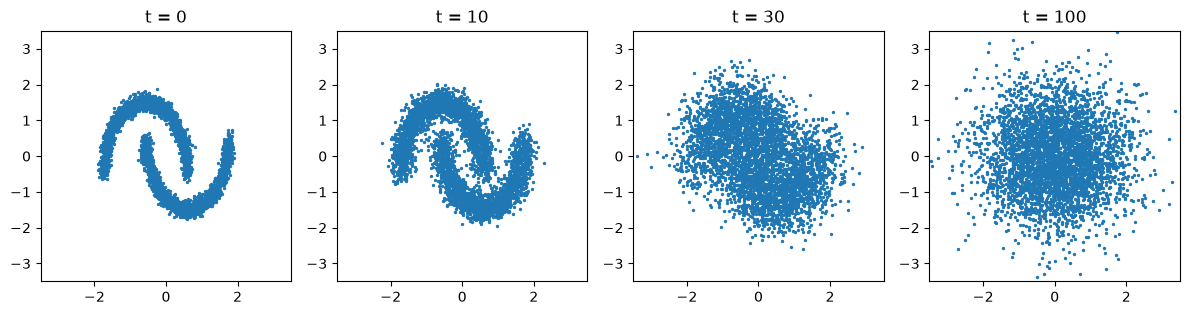

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, step in zip(axes, [0, 10, 30, 100]):
    if step == 0:
        pts = data
    else:
        pts, _ = q_sample(data, torch.full((len(data),), step - 1))
    ax.scatter(pts[:, 0], pts[:, 1], s=2); ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.set_title(f"t = {step}"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

### 5. The epsilon-prediction objective, one step at a time

**What this cell does (plain language):** before building the network, we spell out one training example by hand: pick a random clean point, pick a random timestep, sample noise, build `x_t`, and ask the model to recover the noise. We use a dummy 'model' that predicts all zeros to show what the loss looks like at its starting point: because `eps` has unit variance, the MSE of predicting zero is about 1.0 (for 2 features, per-element). A good model must drive this well below 1. Note that the target is the noise itself, a quantity with the SAME scale at every timestep, which is one reason this parameterisation trains stably.

In [5]:
torch.manual_seed(0)
B_ = 8
x0_batch = data[torch.randint(0, len(data), (B_,))]
t_batch = torch.randint(0, T, (B_,))               # a DIFFERENT random timestep for each sample
xt_batch, eps_batch = q_sample(x0_batch, t_batch)
print("timesteps:", t_batch.tolist())
print("target eps (first 2 rows):", eps_batch[:2].tolist())

pred_zero = torch.zeros_like(eps_batch)
print("MSE of the trivial 'predict zero' model, large batch:",
      round(F.mse_loss(torch.zeros(100000, 2), torch.randn(100000, 2)).item(), 3))

timesteps: [97, 83, 1, 66, 56, 99, 78, 76]
target eps (first 2 rows): [[-1.3526537418365479, -1.6959311962127686], [0.5666506290435791, 0.7935083508491516]]
MSE of the trivial 'predict zero' model, large batch: 1.0


### 6. The denoiser: an MLP conditioned on the timestep

**What this cell does (plain language):** the network must know how noisy its input is, so it takes both `x_t` and the timestep `t`. We turn `t` into a sinusoidal embedding (the same trick as transformer positional encodings: sines and cosines at several frequencies), pass it through a small MLP, and concatenate with `x_t`. The input is `t / T` scaled before embedding. The network outputs 2 numbers: the predicted noise for each coordinate, so output dimension equals data dimension.

In [6]:
def timestep_embedding(t, dim=32):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half) / half)      # geometric ladder of frequencies
    args = t[:, None].float() * freqs[None, :]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)          # (B, dim)

class Denoiser(nn.Module):
    def __init__(self, hidden=128, t_dim=32):
        super().__init__()
        self.t_dim = t_dim
        self.t_mlp = nn.Sequential(nn.Linear(t_dim, hidden), nn.SiLU())
        self.net = nn.Sequential(
            nn.Linear(2 + hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 2))
    def forward(self, x, t):
        te = self.t_mlp(timestep_embedding(t, self.t_dim))
        return self.net(torch.cat([x, te], dim=-1))

torch.manual_seed(0)
model = Denoiser()
print("output shape:", tuple(model(xt_batch, t_batch).shape), "| #params:", sum(p.numel() for p in model.parameters()))
print("embedding of t=0 vs t=1 differ:", not torch.allclose(timestep_embedding(torch.tensor([0])), timestep_embedding(torch.tensor([1]))))

output shape: (8, 2) | #params: 54274
embedding of t=0 vs t=1 differ: True


### 7. Training the denoiser

**What this cell does (plain language):** the training loop is almost embarrassingly simple: sample a batch of data, sample a random timestep per example, noise it with the closed form, and minimise the MSE between predicted and true noise. We use Adam with a fixed learning rate and 3000 steps. The loss is noisy (each batch has random timesteps and noise) so we print an average over blocks of 500 steps; it falls from about 1 toward a floor well above 0. The floor exists because at SMALL `t` the added noise is tiny compared with the natural jitter of the data, so it is nearly impossible to tell which part of `x_t` is noise (Exercise 5 below measures this per timestep); at large `t` the noise dominates `x_t` and is easy to predict.

In [7]:
torch.manual_seed(0)
model = Denoiser()
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
losses = []
for step in range(3000):
    x0 = data[torch.randint(0, len(data), (256,))]
    t = torch.randint(0, T, (256,))
    xt, eps = q_sample(x0, t)
    loss = F.mse_loss(model(xt, t), eps)         # predict the noise
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if (step + 1) % 500 == 0:
        print(f"step {step+1:4d} | mean loss of last 500 steps: {sum(losses[-500:]) / 500:.4f}")
print("loss improved:", sum(losses[-500:]) / 500 < sum(losses[:500]) / 500)

step  500 | mean loss of last 500 steps: 0.5432


step 1000 | mean loss of last 500 steps: 0.5038


step 1500 | mean loss of last 500 steps: 0.4808


step 2000 | mean loss of last 500 steps: 0.4747


step 2500 | mean loss of last 500 steps: 0.4673


step 3000 | mean loss of last 500 steps: 0.4616
loss improved: True


### 8. DDPM sampling: running the reverse process

**What this cell does (plain language):** to generate, we start from pure noise `x_T ~ N(0, I)` and loop `t = T ... 1`. At each step the model predicts the noise in the current `x_t`; we subtract the right fraction of it to get the mean of `x_{t-1}`, then add a fresh bit of Gaussian noise (variance `beta_t`). On the very last step no noise is added, otherwise the output would be needlessly fuzzy. Sampling is decorated with `torch.no_grad()` because we need no gradients, and it is much slower than a GAN or VAE because it calls the network `T` times.

In [8]:
@torch.no_grad()
def p_sample_loop(model, n, return_traj=False):
    x = torch.randn(n, 2)                          # start from pure noise
    traj = [x.clone()]
    for i in reversed(range(T)):                    # i = T-1 ... 0
        t = torch.full((n,), i)
        eps_hat = model(x, t)
        coef = betas[i] / (1 - alpha_bar[i]).sqrt()
        mean = (x - coef * eps_hat) / alphas[i].sqrt()
        if i > 0:
            x = mean + betas[i].sqrt() * torch.randn_like(x)    # add noise except at the final step
        else:
            x = mean
        traj.append(x.clone())
    return (x, traj) if return_traj else x

torch.manual_seed(1)
samples, traj = p_sample_loop(model, 2000, return_traj=True)
print("samples:", tuple(samples.shape))
print("sample mean:", [round(v, 3) for v in samples.mean(0).tolist()], "| sample std:", [round(v, 3) for v in samples.std(0).tolist()])
print("data   mean:", [round(v, 3) for v in data.mean(0).tolist()], "| data   std:", [round(v, 3) for v in data.std(0).tolist()])

samples: (2000, 2)
sample mean: [0.011, -0.02] | sample std: [0.983, 0.979]
data   mean: [-0.0, -0.0] | data   std: [1.0, 1.0]


### 9. How good are the samples?

**What this cell does (plain language):** we judge quality in two ways. (1) A picture: real data next to generated samples. (2) A number: for each generated point, the distance to the closest real training point; for a good sampler this is close to (but, for a small model trained briefly, somewhat above) the value for held-out real points, while for pure Gaussian noise it is far larger because many noise points land in the empty space between and around the moons. We compare three populations: held-out real moons, our samples, and raw Gaussian noise.

mean distance to nearest training point
  held-out real moons : 0.0162
  DDPM samples        : 0.0425
  pure Gaussian noise : 0.233


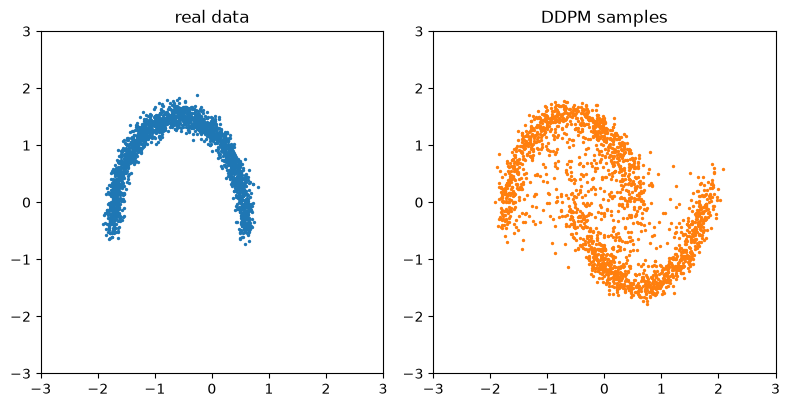

In [9]:
def mean_nn_dist(pts, ref):
    return torch.cdist(pts, ref).min(dim=1).values.mean().item()

torch.manual_seed(2)
real_heldout = make_moons(2000)
real_heldout = (real_heldout - make_moons(4000).mean(0)) / make_moons(4000).std(0)   # same style of normalisation
noise_pts = torch.randn(2000, 2)

print("mean distance to nearest training point")
print("  held-out real moons :", round(mean_nn_dist(real_heldout, data), 4))
print("  DDPM samples        :", round(mean_nn_dist(samples, data), 4))
print("  pure Gaussian noise :", round(mean_nn_dist(noise_pts, data), 4))

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(data[:2000, 0], data[:2000, 1], s=2); ax[0].set_title("real data")
ax[1].scatter(samples[:, 0], samples[:, 1], s=2, c="tab:orange"); ax[1].set_title("DDPM samples")
for a in ax: a.set_xlim(-3, 3); a.set_ylim(-3, 3); a.set_aspect("equal")
plt.tight_layout(); plt.show()

### 10. Epsilon vs x0: the model also knows the clean point

**What this cell does (plain language):** predicting the noise and predicting the clean data are two views of the same thing, because `x_t = sqrt(abar) x_0 + sqrt(1-abar) eps`. Solving for `x_0` gives `x0_hat = (x_t - sqrt(1-abar_t) * eps_hat) / sqrt(abar_t)`. We apply this to held-out noised points at several timesteps and measure how close `x0_hat` is to the true `x_0`. At small `t` the error is small simply because `x_t` is already close to `x_0`; at large `t` the clean point is very ambiguous, so the error is bigger (the prediction approaches an average over plausible data points). The last column shows the model's `x0_hat` is better than just trusting `x_t` at every step.

In [10]:
torch.manual_seed(3)
x0 = data[torch.randint(0, len(data), (2000,))]
print("t   | mean error of x0_hat | mean error if we just use x_t")
with torch.no_grad():
    for i in [4, 19, 49, 79, 99]:
        t = torch.full((2000,), i)
        xt, eps = q_sample(x0, t)
        eps_hat = model(xt, t)
        x0_hat = (xt - (1 - alpha_bar[i]).sqrt() * eps_hat) / alpha_bar[i].sqrt()
        print(f"{i+1:3d} | {(x0_hat - x0).norm(dim=1).mean().item():20.3f} | {(xt - x0).norm(dim=1).mean().item():.3f}")

t   | mean error of x0_hat | mean error if we just use x_t
  5 |                0.086 | 0.093
 20 |                0.316 | 0.390
 50 |                0.815 | 0.929
 80 |                1.144 | 1.342
100 |                1.271 | 1.486


### 11. A different schedule: cosine vs linear

**What this cell does (plain language):** the noise schedule is a design choice. The cosine schedule (Nichol & Dhariwal) defines `abar_t` directly as `cos^2(((t/T)+s)/(1+s) * pi/2)` normalised to 1 at `t=0`, designed to avoid wasting steps at the extremes. Compared with our linear schedule, it keeps slightly LESS signal in the middle of the chain and reaches `abar` of essentially 0 at `t=T`, whereas our linear schedule still has `abar_T` about 0.08 (a little signal left at the end). We compute it and compare. We do not retrain here; the point is that the forward process only needs a decreasing `abar` sequence, and `betas` can be recovered from it as `beta_t = 1 - abar_t / abar_{t-1}` (clipped to stay below 1 for stability).

In [11]:
def cosine_alpha_bar(T, s=0.008):
    steps = torch.arange(T + 1) / T
    f = torch.cos((steps + s) / (1 + s) * math.pi / 2) ** 2
    return (f / f[0])                               # length T+1, abar_0 = 1

ab_cos = cosine_alpha_bar(T)
betas_cos = (1 - ab_cos[1:] / ab_cos[:-1]).clamp(max=0.999)
print("t    | abar linear | abar cosine")
for i in [10, 25, 50, 75, 100]:
    print(f"{i:4d} | {alpha_bar[i-1]:11.4f} | {ab_cos[i]:.4f}")
print("final abar: linear", round(alpha_bar[-1].item(), 4), "| cosine", round(ab_cos[-1].item(), 6))
print("recovered betas are valid (0<beta<1):", bool(((betas_cos > 0) & (betas_cos < 1)).all()))

t    | abar linear | abar cosine
  10 |      0.9766 | 0.9721
  25 |      0.8570 | 0.8470
  50 |      0.5338 | 0.4938
  75 |      0.2407 | 0.1443
 100 |      0.0782 | 0.0000
final abar: linear 0.0782 | cosine 0.0
recovered betas are valid (0<beta<1): True


## Common bugs

- **Indexing the schedule with `t` off by one**
  Using 1-based `t` with 0-based tensors (`alpha_bar[t]` with `t = T`) raises an index error or uses the wrong noise level. Fix: pick one convention and stick to it (here: tensor index `i` means step `i+1`).
- **Forgetting the square roots in `q_sample`**
  `x_t = abar * x0 + (1 - abar) * eps` has the wrong variance and the process does not end at N(0, I). Fix: `sqrt(abar)` on the signal and `sqrt(1 - abar)` on the noise.
- **Not broadcasting the per-sample schedule value**
  `alpha_bar[t]` has shape `(B,)` and silently broadcasts against `(B, 2)` along the wrong axis (or errors when B == 2). Fix: `alpha_bar[t][:, None]`.
- **Using one timestep for the whole batch**
  The model only ever sees one noise level per step, so training is high-variance. Fix: draw an independent `t` per sample.
- **Feeding the model no timestep (or an un-embedded raw integer)**
  A single network cannot guess the noise level from `x_t` alone, and raw integers like 0..99 are hard to use. Fix: sinusoidal (or learned) timestep embedding.
- **Adding noise on the final sampling step**
  The generated points stay slightly fuzzy. Fix: `z = 0` when `t == 1`.
- **Wrong sign / coefficient in the reverse step**
  `x_{t-1} = (x_t - beta_t/sqrt(1-abar_t) * eps_hat) / sqrt(alpha_t)`; mixing up `alpha` and `abar`, or adding instead of subtracting, makes samples explode or collapse.
- **Sampling without `torch.no_grad()` / without `model.eval()`**
  Builds a huge graph over T steps (memory) and applies dropout/batchnorm in training mode if the model has any. Fix: `@torch.no_grad()` and `model.eval()`.
- **Unnormalised data**
  The schedule assumes roughly unit-variance data; with large-scale data the noise is too weak and the model sees a different distribution at t = T than N(0, I). Fix: standardise (or scale to [-1, 1] for images).

## Exercises

Attempt each one in the empty cell right after it, then compare with the solution below.

**Exercise 1 - Signal-to-noise ratio.**
Compute `SNR_t = abar_t / (1 - abar_t)` for the linear schedule and find the first step where SNR drops below 1 (signal variance < noise variance).

In [12]:
# Your attempt for Exercise 1 here

**Solution 1**

In [13]:
# Solution 1
snr = alpha_bar / (1 - alpha_bar)
first = (snr < 1).nonzero()[0].item() + 1
print("SNR at t=1:", round(snr[0].item(), 1), "| t=T:", round(snr[-1].item(), 5), "| first step with SNR<1: t =", first)

SNR at t=1: 9997.3 | t=T: 0.08487 | first step with SNR<1: t = 53


**Exercise 2 - Posterior variance.**
The true reverse-step variance is `beta_tilde_t = (1 - abar_{t-1}) / (1 - abar_t) * beta_t`. Compute it (with `abar_0 = 1`) and compare with `beta_t` (the simpler choice we used). Where do they differ most?

In [14]:
# Your attempt for Exercise 2 here

**Solution 2**

In [15]:
# Solution 2
ab_prev = torch.cat([torch.ones(1), alpha_bar[:-1]])
beta_tilde = (1 - ab_prev) / (1 - alpha_bar) * betas
print("ratio beta_tilde/beta at t=1,2,5,50,100:", [round(beta_tilde[i].item() / betas[i].item(), 3) for i in [0, 1, 4, 49, 99]])
print("They differ only at the first few steps; at larger t they are nearly equal.")

ratio beta_tilde/beta at t=1,2,5,50,100: [0.0, 0.142, 0.619, 0.971, 0.996]
They differ only at the first few steps; at larger t they are nearly equal.


**Exercise 3 - Sample with fewer steps.**
Call the trained model on a strided subset of timesteps (every 2nd step) WITHOUT changing the formula. What goes wrong, and why does DDIM or re-derived coefficients fix it?

In [16]:
# Your attempt for Exercise 3 here

**Solution 3**

In [17]:
# Solution 3
@torch.no_grad()
def naive_strided(model, n, stride=2):
    x = torch.randn(n, 2)
    for i in reversed(range(0, T, stride)):
        eps_hat = model(x, torch.full((n,), i))
        x = (x - betas[i] / (1 - alpha_bar[i]).sqrt() * eps_hat) / alphas[i].sqrt()
        if i > 0: x = x + betas[i].sqrt() * torch.randn_like(x)
    return x
torch.manual_seed(0)
s2 = naive_strided(model, 2000)
print("full sampler NN distance:", round(mean_nn_dist(samples, data), 3), "| naive strided:", round(mean_nn_dist(s2, data), 3))
print("Each skipped step removes noise that the formula assumes was removed, so the samples stay too noisy; fixes need coefficients re-derived for the larger jump (DDIM).")

full sampler NN distance: 0.042 | naive strided: 0.066
Each skipped step removes noise that the formula assumes was removed, so the samples stay too noisy; fixes need coefficients re-derived for the larger jump (DDIM).


**Exercise 4 - Predict x0 instead of epsilon.**
Train a second network with the target `x0` instead of `eps` (800 steps is enough to see the loss fall), then write the sampling-time conversion `eps_hat = (x_t - sqrt(abar) x0_hat) / sqrt(1-abar)`. Print the final loss of the first and last 100 steps.

In [18]:
# Your attempt for Exercise 4 here

**Solution 4**

In [19]:
# Solution 4
torch.manual_seed(0)
m0 = Denoiser(); o = torch.optim.Adam(m0.parameters(), lr=2e-3); ls = []
for step in range(800):
    x0 = data[torch.randint(0, len(data), (256,))]
    t = torch.randint(0, T, (256,))
    xt, eps = q_sample(x0, t)
    loss = F.mse_loss(m0(xt, t), x0)               # target is the clean data
    o.zero_grad(); loss.backward(); o.step(); ls.append(loss.item())
print("loss first 100:", round(sum(ls[:100]) / 100, 3), "| last 100:", round(sum(ls[-100:]) / 100, 3))
def eps_from_x0(xt, x0_hat, i):
    return (xt - alpha_bar[i].sqrt() * x0_hat) / (1 - alpha_bar[i]).sqrt()
print("conversion shape check:", tuple(eps_from_x0(xt, m0(xt, t), 10).shape))

loss first 100: 0.529 | last 100: 0.43
conversion shape check: (256, 2)


**Exercise 5 - Loss per timestep.**
Evaluate the trained epsilon model's MSE separately at t = 1, 25, 50, 75, 100 on 5000 noised points. At which end is predicting the noise hardest, and why?

In [20]:
# Your attempt for Exercise 5 here

**Solution 5**

In [21]:
# Solution 5
torch.manual_seed(0)
with torch.no_grad():
    for i in [0, 24, 49, 74, 99]:
        x0 = data[torch.randint(0, len(data), (5000,))]
        t = torch.full((5000,), i)
        xt, eps = q_sample(x0, t)
        print(f"t={i+1:3d} | eps MSE {F.mse_loss(model(xt, t), eps).item():.4f}")
print("Small t is hardest (MSE near 1 = no better than guessing zero): the noise is tiny relative to the data jitter. Large t is easy: x_t is almost pure noise.")

t=  1 | eps MSE 1.0251
t= 25 | eps MSE 0.6635
t= 50 | eps MSE 0.4866
t= 75 | eps MSE 0.2348
t=100 | eps MSE 0.0792
Small t is hardest (MSE near 1 = no better than guessing zero): the noise is tiny relative to the data jitter. Large t is easy: x_t is almost pure noise.


**Exercise 6 - Exponential moving average of weights.**
Create an EMA copy of the trained model with decay 0.99 and update it over 200 extra training steps. Sample from the EMA and from the raw model and compare the nearest-neighbour distance.

In [22]:
# Your attempt for Exercise 6 here

**Solution 6**

In [23]:
# Solution 6
import copy
ema = copy.deepcopy(model)
opt2 = torch.optim.Adam(model.parameters(), lr=1e-3)
for step in range(200):
    x0 = data[torch.randint(0, len(data), (256,))]
    t = torch.randint(0, T, (256,))
    xt, eps = q_sample(x0, t)
    loss = F.mse_loss(model(xt, t), eps)
    opt2.zero_grad(); loss.backward(); opt2.step()
    with torch.no_grad():
        for pe, p in zip(ema.parameters(), model.parameters()):
            pe.mul_(0.99).add_(p, alpha=0.01)
torch.manual_seed(5)
print("raw model NN dist:", round(mean_nn_dist(p_sample_loop(model, 1000), data), 4), "| EMA model NN dist:", round(mean_nn_dist(p_sample_loop(ema, 1000), data), 4))

raw model NN dist: 0.0427 | EMA model NN dist: 0.0395
